In [94]:
!nvidia-smi

Fri Jun  5 15:58:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             32W /   70W |     153MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [74]:
import torch
import torchvision
import matplotlib
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

print(matplotlib.__version__)

2.11.0+cu128
0.26.0+cu128
3.10.0


In [75]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla T4


In [76]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [77]:
x=torch.randn(3,64,64)
print(x.shape,
x.dtype,
x.device)

torch.Size([3, 64, 64]) torch.float32 cpu


In [78]:
x_gpu=x.to(device)
print(x_gpu.device,
      x_gpu.shape)

cuda:0 torch.Size([3, 64, 64])


In [79]:
x_gpu_0=x_gpu[0]
X=x_gpu_0@x_gpu_0
print(X.shape,X.device)

torch.Size([64, 64]) cuda:0


In [80]:
import os
import random
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import DataLoader,random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision
import matplotlib.pyplot as plt


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)





Using: cuda


In [81]:
RAW_ROOT = Path("galaxy_raw")
IMAGES_DIR = RAW_ROOT / "images_gz2"/"images"
DATA_ROOT = Path("galaxy_data")
LABELS_URL = "https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz"


from google.colab import files
files.upload()  # select kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!pip -q install kaggle pandas
!kaggle datasets download -d jaimetrickz/galaxy-zoo-2-images
!unzip -q -o galaxy-zoo-2-images.zip -d {RAW_ROOT}

!wget -q -O {RAW_ROOT}/gz2_hart16.csv.gz {LABELS_URL}
!gunzip -f {RAW_ROOT}/gz2_hart16.csv.gz

print("RAW_ROOT   =", RAW_ROOT)
print("IMAGES_DIR =", IMAGES_DIR)
print("DATA_ROOT  =", DATA_ROOT)

Saving kaggle(1).json to kaggle(1) (5).json
Dataset URL: https://www.kaggle.com/datasets/jaimetrickz/galaxy-zoo-2-images
License(s): Attribution 4.0 International (CC BY 4.0)
galaxy-zoo-2-images.zip: Skipping, found more recently modified local copy (use --force to force download)
RAW_ROOT   = galaxy_raw
IMAGES_DIR = galaxy_raw/images_gz2/images
DATA_ROOT  = galaxy_data


In [82]:
print("RAW_ROOT contents:", sorted(p.name for p in RAW_ROOT.iterdir()))
jpg_count = sum(1 for _ in IMAGES_DIR.glob("*.jpg"))
print(f"Flat JPG count in {IMAGES_DIR}: {jpg_count:,}")

mapping_head = pd.read_csv(RAW_ROOT / "gz2_filename_mapping.csv", nrows=3)
print(mapping_head)



RAW_ROOT contents: ['gz2_filename_mapping.csv', 'gz2_hart16.csv', 'images_gz2']
Flat JPG count in galaxy_raw/images_gz2/images: 243,434
                objid    sample  asset_id
0  587722981736120347  original         1
1  587722981736579107  original         2
2  587722981741363294  original         3


In [83]:
def high_level_label(gz2_class: str):
    """Collapse detailed GZ2 morphology codes to a few training buckets."""
    if not gz2_class or gz2_class == "A":
        return None
    if gz2_class.startswith("E"):
        return "elliptical"
    if gz2_class.startswith("SB"):
        return "spiral_barred"
    if gz2_class.startswith("S"):
        return "spiral"
    return None


def build_imagefolder_layout(
    images_dir,
    mapping_csv,
    labels_csv,
    out_root,
    per_class=200,
    seed=42,
):
    """Symlink a balanced subset into out_root// for ImageFolder."""
    mapping = pd.read_csv(mapping_csv)
    labels = pd.read_csv(labels_csv).rename(columns={"dr7objid": "objid"})
    df = mapping.merge(labels[["objid", "gz2_class"]], on="objid", how="inner")
    df["label"] = df["gz2_class"].map(high_level_label)
    df = df.dropna(subset=["label"])

    images_dir = Path(images_dir)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    counts = {}
    for label in sorted(df["label"].unique()):
        class_dir = out_root / label
        class_dir.mkdir(exist_ok=True)
        rows = df[df["label"] == label]
        if len(rows) > per_class:
            rows = rows.sample(n=per_class, random_state=seed)
        linked = 0
        for _, row in rows.iterrows():
            src = images_dir / f"{int(row.asset_id)}.jpg"
            dst = class_dir / f"{int(row.asset_id)}.jpg"
            if src.exists() and not dst.exists():
                os.symlink(src.resolve(), dst)
                linked += 1
        counts[label] = linked
    return counts

PER_CLASS = 200  # balanced subset — fast on Colab; increase once the pipeline works
counts = build_imagefolder_layout(
    IMAGES_DIR,
    RAW_ROOT / "gz2_filename_mapping.csv",
    RAW_ROOT / "gz2_hart16.csv",
    DATA_ROOT,
    per_class=PER_CLASS,
)
print("Symlinked per class:", counts)
print("DATA_ROOT classes:", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))


Symlinked per class: {'elliptical': 0, 'spiral': 0, 'spiral_barred': 0}
DATA_ROOT classes: ['elliptical', 'spiral', 'spiral_barred']


In [89]:


transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])



In [90]:
dataset = ImageFolder(root=DATA_ROOT, transform=transform)
print("num images   :", len(dataset))
print("classes      :", dataset.classes)
print("class_to_idx :", dataset.class_to_idx)

num images   : 600
classes      : ['elliptical', 'spiral', 'spiral_barred']
class_to_idx : {'elliptical': 0, 'spiral': 1, 'spiral_barred': 2}


In [91]:
image, label = dataset[0]
print("shape :", image.shape)   # torch.Size([3, 64, 64])
print("dtype :", image.dtype)   # torch.float32
print("label :", label, "->", dataset.classes[label])

shape : torch.Size([3, 64, 64])
dtype : torch.float32
label : 0 -> elliptical


In [92]:


loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

images, labels = next(iter(loader))
print("images:", images.shape)   # (32, 3, 64, 64) = (B, C, H, W)
print("labels:", labels.shape)   # (32,)



images: torch.Size([32, 3, 64, 64])
labels: torch.Size([32])


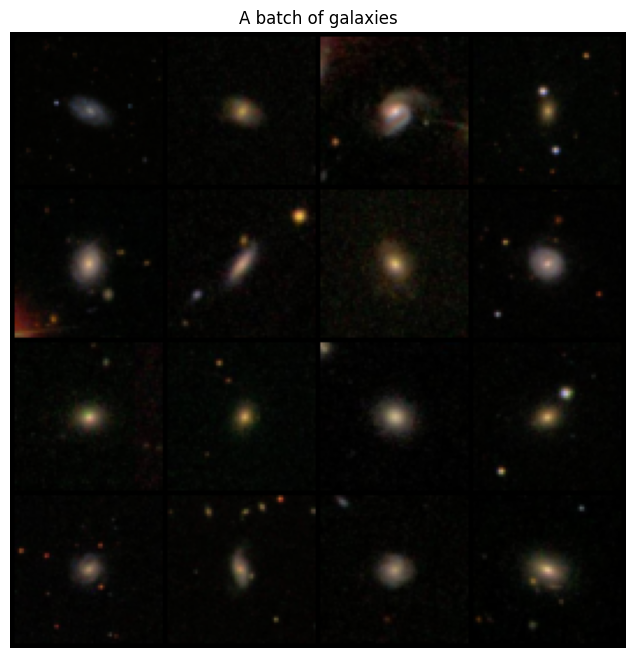

Labels: ['spiral_barred', 'spiral_barred', 'spiral_barred', 'spiral', 'spiral', 'spiral', 'spiral', 'spiral', 'elliptical', 'spiral', 'elliptical', 'spiral', 'spiral_barred', 'spiral', 'spiral_barred', 'elliptical']


In [93]:


images_show = images * 0.5 + 0.5
grid = torchvision.utils.make_grid(images_show[:16], nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("A batch of galaxies")
plt.show()

print("Labels:", [dataset.classes[i] for i in labels[:16].tolist()])


In [98]:
!git clone https://github.com/GittohubbonoAkuma/CSOT_astronomy.git

Cloning into 'CSOT_astronomy'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [101]:
%cd /content/CSOT_astronomy
!cp /content/Week1_tensors.ipynb .
!ls

/content/CSOT_astronomy
cp: cannot stat '/content/Week1_tensors.ipynb': No such file or directory
README.md


In [103]:
!find /content -name "*.ipynb"